I chose a car-sales dataset from Kaggle.

Application and use cases of the dataset:

1) Market Analysis: Evaluate overall trends and regional variations in car sales to assess manufacturer performance, model preferences, and demographic insights.
2) Seasonal Patterns and Competitor Analysis: Investigate seasonal and cyclical patterns in sales.
3) Forecasting and Predictive Analysis Use historical data for forecasting and predict future market trends. Support marketing, advertising, and investment decisions based on insights.
4) Supply Chain and Inventory Optimization: Provide valuable data for stakeholders in the automotive industry.

Import packages

In [59]:
import pandas as pd
import numpy as np

Load the dataset

In [60]:
car_sales = pd.read_csv('car_sales.csv')

# Clean whitespace from all column names
car_sales.columns = car_sales.columns.str.strip()

In [61]:
car_sales.shape

(23906, 16)

The dataset includes 23906 rows and 16 columns

In [62]:
car_sales.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [63]:
car_sales.dtypes #names of columns and data types

Car_id           object
Date             object
Customer Name    object
Gender           object
Annual Income     int64
Dealer_Name      object
Company          object
Model            object
Engine           object
Transmission     object
Color            object
Price ($)         int64
Dealer_No        object
Body Style       object
Phone             int64
Dealer_Region    object
dtype: object

All columns 

The names of the columns include date of purchase, manufacturer of te car and its parameters such as motor, model, color.

In addition, the dataset includes the price of the car and the customer's and delaer's data.

Checking if there are missing values:

In [64]:
print(car_sales.isnull().sum())

Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64


Because only one row has a missing value, the best way to deal with it is to simply delete this specific row.
remove the row with missing values:

In [65]:
car_sales = car_sales.dropna()

In [66]:
print(car_sales.isnull().sum()) #check that all empty values were romoved from the dataset

Car_id           0
Date             0
Customer Name    0
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64


Check if there are duplicates:

In [67]:
# Count total duplicate rows
print("Duplicate rows count:", car_sales.duplicated().sum())

Duplicate rows count: 0


In [68]:
# Check for potential duplicate transactions
duplicate_sales = car_sales[car_sales.duplicated(
    subset=['Date', 'Customer Name', 'Phone', 'Model', 'Price ($)'], 
    keep=False
)]
print(f"Potential duplicate sales: {len(duplicate_sales)}")

Potential duplicate sales: 0


In [69]:
# View the specific rows with conflicting dealer names
dealer_mismatches = car_sales.groupby('Dealer_No')['Dealer_Name'].nunique()
inconsistent_dealers = dealer_mismatches[dealer_mismatches > 1]

print("Dealer IDs associated with multiple names:")
print(inconsistent_dealers)

Dealer IDs associated with multiple names:
Dealer_No
06457-3834    4
38701-8047    4
53546-9427    4
60504-7114    4
78758-7841    4
85257-3102    4
99301-3882    4
Name: Dealer_Name, dtype: int64


In [70]:
# Check if a single Dealer_Name is assigned to multiple Dealer_Nos
name_mismatches = car_sales.groupby('Dealer_Name')['Dealer_No'].nunique()
inconsistent_names = name_mismatches[name_mismatches > 1]

print("Dealer Names associated with multiple IDs:")
print(inconsistent_names)

Dealer Names associated with multiple IDs:
Series([], Name: Dealer_No, dtype: int64)


### Dealer Identity Integrity Check
- **Dealer_No -> Dealer_Name:** Inconsistencies detected. Some `Dealer_No` values map to multiple name variations (likely due to string formatting or data entry typos).
- **Dealer_Name -> Dealer_No:** 100% Consistent. No `Dealer_Name` maps to multiple distinct IDs.

### Data Cleaning: Standardizing Dealer Names
To resolve the partial duplicate inconsistency where single `Dealer_No` values mapped to multiple `Dealer_Name` variations, a 1-to-1 mapping dictionary was generated based on the primary record. All `Dealer_Name` entries were updated accordingly to ensure data consistency across the dataset.

In [71]:
# 1. Identify and select a single, standardized Dealer_Name for each Dealer_No
# (Taking the first occurring name for each Dealer_No)
dealer_mapping = car_sales.groupby('Dealer_No')['Dealer_Name'].first().to_dict()

# 2. Map the standardized names back to the dataset
car_sales['Dealer_Name'] = car_sales['Dealer_No'].map(dealer_mapping)

# 3. Verification: Re-check if any Dealer_No still has multiple names
remaining_mismatches = car_sales.groupby('Dealer_No')['Dealer_Name'].nunique()
inconsistent_after_fix = remaining_mismatches[remaining_mismatches > 1]

print(f"Number of inconsistent Dealer IDs after fix: {len(inconsistent_after_fix)}")

Number of inconsistent Dealer IDs after fix: 0


In [72]:
# Check if Car_id contains any duplicates
duplicate_car_ids = car_sales[car_sales.duplicated(subset=['Car_id'], keep=False)]

print(f"Number of duplicate Car_id entries: {len(duplicate_car_ids)}")

# Display the duplicate Car_id rows if any exist
if not duplicate_car_ids.empty:
    print(duplicate_car_ids.sort_values(by='Car_id'))

Number of duplicate Car_id entries: 0


In [73]:
# Check if a single Phone number maps to multiple different Customer Names
phone_name_conflicts = car_sales.groupby('Phone')['Customer Name'].nunique()
inconsistent_customer_names = phone_name_conflicts[phone_name_conflicts > 1]

print(f"Phone numbers associated with multiple customer names: {len(inconsistent_customer_names)}")

# Check if a single Phone number maps to multiple different Annual Income values
phone_income_conflicts = car_sales.groupby('Phone')['Annual Income'].nunique()
inconsistent_customer_incomes = phone_income_conflicts[phone_income_conflicts > 1]

print(f"Phone numbers associated with multiple income levels: {len(inconsistent_customer_incomes)}")

Phone numbers associated with multiple customer names: 102
Phone numbers associated with multiple income levels: 94


### Data Cleaning: Resolving Customer Profile Conflicts
Analysis revealed that 102 phone numbers were linked to multiple customer names, and 94 were linked to conflicting annual income levels (likely due to family sharing or data entry updates). 
To enforce profile consistency, a 1-to-1 mapping was applied based on the first recorded entry for each phone number, standardizing both `Customer Name` and `Annual Income`.

In [74]:
# 1. Create mapping dictionaries for Customer Name and Annual Income based on Phone number
# (Using the first occurrence to establish a standard profile per Phone)
name_mapping = car_sales.groupby('Phone')['Customer Name'].first().to_dict()
income_mapping = car_sales.groupby('Phone')['Annual Income'].first().to_dict()

# 2. Map the standardized values back to the dataset to overwrite inconsistencies
car_sales['Customer Name'] = car_sales['Phone'].map(name_mapping)
car_sales['Annual Income'] = car_sales['Phone'].map(income_mapping)

# 3. Verification: Re-check conflicts
phone_name_conflicts = car_sales.groupby('Phone')['Customer Name'].nunique()
remaining_name_conflicts = phone_name_conflicts[phone_name_conflicts > 1]

phone_income_conflicts = car_sales.groupby('Phone')['Annual Income'].nunique()
remaining_income_conflicts = phone_income_conflicts[phone_income_conflicts > 1]

print(f"Remaining phone-name conflicts after fix: {len(remaining_name_conflicts)}")
print(f"Remaining phone-income conflicts after fix: {len(remaining_income_conflicts)}")

Remaining phone-name conflicts after fix: 0
Remaining phone-income conflicts after fix: 0


In [75]:
# Convert 'Date' column to datetime format
car_sales['Date'] = pd.to_datetime(car_sales['Date'])

# Verify conversion
print(f"New Date dtype: {car_sales['Date'].dtype}")

New Date dtype: datetime64[ns]


**Date Column:** Converted from `object` to `datetime64[ns]` using `pd.to_datetime()` to enable time-series analysis.

In [76]:
# Display current data types for all columns
print(car_sales.dtypes)

Car_id                   object
Date             datetime64[ns]
Customer Name            object
Gender                   object
Annual Income             int64
Dealer_Name              object
Company                  object
Model                    object
Engine                   object
Transmission             object
Color                    object
Price ($)                 int64
Dealer_No                object
Body Style               object
Phone                     int64
Dealer_Region            object
dtype: object


### Suspicious Values Analysis
- **Negative / Zero Values:** Validated that numerical attributes (`Price ($)`, `Annual Income`) contain strictly positive values.
- **Placeholder Values:** Checked for artificial text markers (`Unknown`, `N/A`, `Test`) in categorical features.
- **Extreme Outliers:** Inspected min/max distributions via `describe()` to locate unrealistic price or income points.
- **Data Quality Insight:** Suspicious values often indicate system input defaults, manual entry errors, or lack of front-end validation during sales capture.

In [77]:
# Check for negative or zero values in numerical features
invalid_prices = car_sales[car_sales['Price ($)'] <= 0]
invalid_income = car_sales[car_sales['Annual Income'] <= 0]

print(f"Rows with invalid Price (<= 0): {len(invalid_prices)}")
print(f"Rows with invalid Annual Income (<= 0): {len(invalid_income)}")

Rows with invalid Price (<= 0): 0
Rows with invalid Annual Income (<= 0): 0


In [78]:
# List of common text placeholder values
placeholder_patterns = ['unknown', 'n/a', 'none', 'test', 'null', '-']

# Function to search for string placeholders across categorical columns
text_cols = ['Customer Name', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color', 'Body Style', 'Dealer_Region']

for col in text_cols:
    matches = car_sales[col].astype(str).str.lower().isin(placeholder_patterns).sum()
    if matches > 0:
        print(f"Column '{col}' has {matches} placeholder values.")
        break

print("No issues found")

No issues found


In [79]:
# Summary of numerical min, max, and quantiles to spot extreme values
print("--- Numerical Distribution & Extremes ---")
print(car_sales[['Price ($)', 'Annual Income']].describe().T[['min', '25%', '50%', '75%', 'max']])

--- Numerical Distribution & Extremes ---
                   min       25%       50%        75%         max
Price ($)       1200.0   18001.0   23000.0    34000.0     85800.0
Annual Income  10080.0  385000.0  735000.0  1175000.0  11200000.0


### Suspicious Values Summary
- **Numerical Features:** Verified that `Price ($)` and `Annual Income` contain positive, realistic values without negative/zero outliers.
- **Categorical Placeholders:** Checked for dummy/placeholder values across text features.

### Extremes & Distribution Analysis (Numerical Outliers)

- **Price ($) Evaluation:**


  - Prices range from **$1,200** to **$85,800**, with a median price of **$23,000**.
  - The values are physically and commercially realistic with no negative or zero invalid entries.

- **Annual Income Evaluation (Right-Skewed Data):**
  - Annual income exhibits extreme high-end variability (Min: **$10,080**, Max: **$11,200,000**).
  - The median income (**$735,000**) is significantly more representative than the mean due to the heavy right-tail distribution.

- **Analytical Takeaway:** 
  - High-income extreme values reflect legitimate high-net-worth buyers rather than data corruption. Therefore, these records should be **retained**, but robust metrics (e.g., Median / IQR) should be prioritized over Mean / Standard Deviation in descriptive analysis.

### Cardinality Analysis

- **Single-Value Columns (Zero Variance):** Checked for redundant features containing only a single unique value across all records (which provide no predictive or descriptive signal).
- **High Cardinality Features:** Identified features with a high proportion of distinct values (e.g., `Car_id`, `Phone`, `Customer Name`), distinguishing primary identifiers from lower-cardinality categorical attributes (e.g., `Gender`, `Body Style`, `Transmission`).
- **Data Action:** Any constant zero-variance features are flagged for removal to optimize dataset footprint and model efficiency.

In [80]:
# 1. Calculate number of unique values for each column
cardinality = car_sales.nunique()

# 2. Convert to DataFrame for structured displaying
cardinality_df = pd.DataFrame({
    'Unique_Values': cardinality,
    'Percentage_Unique (%)': (cardinality / len(car_sales) * 100).round(2),
    'Data_Type': car_sales.dtypes
}).sort_values(by='Unique_Values', ascending=True)

print("--- Cardinality Analysis Summary ---")
print(cardinality_df)

print("\n-----------------------------------")
# 3. Check for Zero Variance Columns (Single value columns)
zero_variance_cols = cardinality_df[cardinality_df['Unique_Values'] == 1].index.tolist()
if zero_variance_cols:
    print(f"Columns with a SINGLE value (Zero Variance): {zero_variance_cols}")
else:
    print("No single-value (zero-variance) columns found.")

# 4. Check for High Cardinality Categorical Columns
high_cardinality_cols = cardinality_df[
    (cardinality_df['Unique_Values'] > 50) & (cardinality_df['Data_Type'] == 'object')
].index.tolist()
print(f"High-cardinality categorical columns (>50 unique values): {high_cardinality_cols}")

--- Cardinality Analysis Summary ---
               Unique_Values  Percentage_Unique (%)       Data_Type
Gender                     2                   0.01          object
Engine                     2                   0.01          object
Transmission               2                   0.01          object
Color                      3                   0.01          object
Body Style                 5                   0.02          object
Dealer_Name                7                   0.03          object
Dealer_No                  7                   0.03          object
Dealer_Region              7                   0.03          object
Company                   30                   0.13          object
Model                    154                   0.64          object
Date                     612                   2.56  datetime64[ns]
Price ($)                870                   3.64           int64
Annual Income           2500                  10.46           int64
Customer Na

### Cardinality Analysis Summary

- **Zero Variance Columns (Single Value):** 
  - **Findings:** No constant/single-value columns were detected in the dataset (`No single-value columns found`).
  - **Conclusion:** Every feature provides data variance and contributes analytical value.

- **High Cardinality Features:** 
  - **Findings:** High cardinality (>50 unique values) was identified in `'Car_id'`, `'Customer Name'`, `'Phone'`, and `'Model'`.
  - **Analytical Takeaway:** 
    - `'Car_id'`, `'Customer Name'`, and `'Phone'` act as high-cardinality row identifiers.
    - `'Model'` represents a high-cardinality categorical variable. If categorical encoding (e.g., One-Hot Encoding) is required for predictive modeling later, `'Model'` will require grouping or advanced target encoding to prevent excessive dimensionality.

## Univariate Analysis

--- Univariate Numerical Statistics ---
                    Mean        Std  Median (50%)       IQR    Min       Max  \
Price ($)       28089.54   14788.59       23000.0   15999.0   1200     85800   
Annual Income  830651.94  720624.10      735000.0  790000.0  10080  11200000   

               Skewness  
Price ($)          1.47  
Annual Income      1.74  


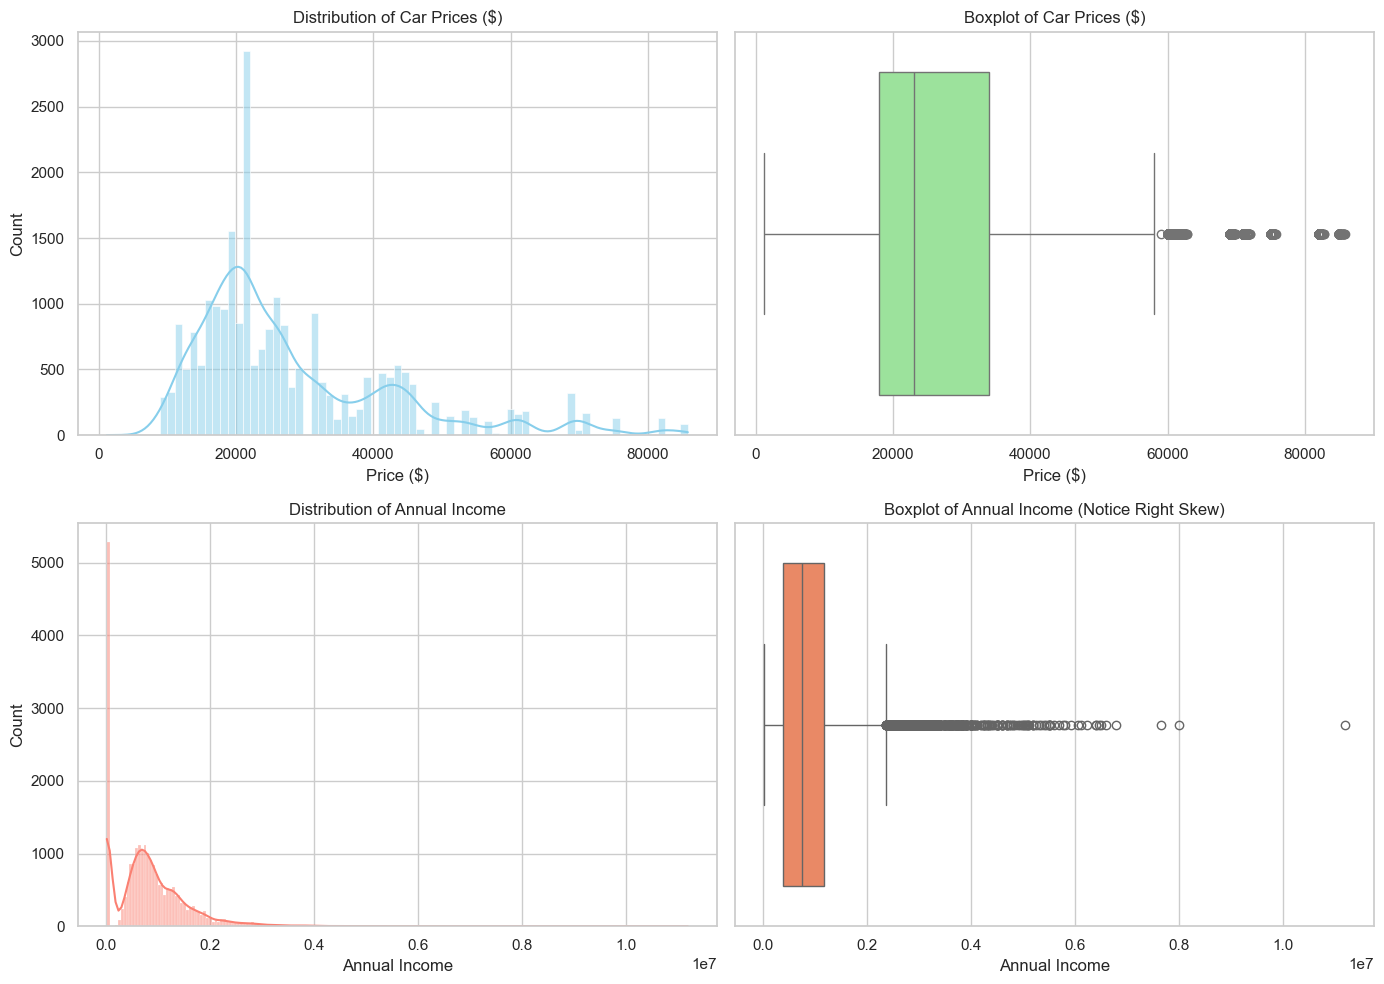

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Summary Statistics focused on Robust Metrics (Median, IQR)
num_cols = ['Price ($)', 'Annual Income']
summary_stats = pd.DataFrame({
    'Mean': car_sales[num_cols].mean(),
    'Std': car_sales[num_cols].std(),
    'Median (50%)': car_sales[num_cols].median(),
    'IQR': car_sales[num_cols].quantile(0.75) - car_sales[num_cols].quantile(0.25),
    'Min': car_sales[num_cols].min(),
    'Max': car_sales[num_cols].max(),
    'Skewness': car_sales[num_cols].skew()
})

print("--- Univariate Numerical Statistics ---")
print(summary_stats.round(2))

# 2. Visualizations for Numerical Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price ($) Distribution
sns.histplot(car_sales['Price ($)'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Car Prices ($)')

sns.boxplot(x=car_sales['Price ($)'], ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Boxplot of Car Prices ($)')

# Annual Income Distribution
sns.histplot(car_sales['Annual Income'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Annual Income')

sns.boxplot(x=car_sales['Annual Income'], ax=axes[1, 1], color='coral')
axes[1, 1].set_title('Boxplot of Annual Income (Notice Right Skew)')

plt.tight_layout()
plt.show()

### Numerical Variables Analysis Summary

Central Tendency & Dispersion Highlights:

- Price (USD):
  Mean vs. Median: Mean (28,089.54 USD) is higher than Median (23,000.00 USD), driven by high-end vehicle sales.
  Spread: Standard deviation is 14,788.59 USD, with an IQR of 15,999.00 USD representing the middle 50% of car prices.
  Skewness: 1.47 (Moderate-to-strong positive right skew).

- Annual Income (USD):
  Mean vs. Median: Mean (830,651.94 USD) is noticeably higher than the Median (735,000.00 USD), confirming the distorting impact of extreme high earners with maximum reaching 11,200,000 USD.
  Spread: High variability with an IQR of 790,000.00 USD and Standard Deviation of 720,624.10 USD.
  Skewness: 1.74 (Strong positive right skew).

Key Takeaway:
Due to the positive skewness and long right tails in both features, robust non-parametric metrics (Median and IQR) provide a more faithful representation of central tendency and spread than standard Parametric metrics (Mean and Standard Deviation).

### Categorical Variables Analysis

In [82]:
def analyze_categorical(data_frame, col, k=3, p_cutoff=80):
    total = len(data_frame)
    counts = data_frame[col].value_counts()
    pcts = (counts / total) * 100
    cum_pcts = pcts.cumsum()
    
    # 1. Mode
    mode_val = counts.index[0]
    mode_pct = pcts.iloc[0]
    
    # 2. Top K categories coverage
    top_k_pct = cum_pcts.iloc[min(k-1, len(counts)-1)]
    
    # 3. Min categories for P% coverage
    p_idx = (cum_pcts >= p_cutoff).idxmax()
    p_count = cum_pcts.index.get_loc(p_idx) + 1
    
    # 4. Rare categories (< 1%)
    rare_mask = pcts < 1
    rare_count = rare_mask.sum()
    rare_pct = pcts[rare_mask].sum()
    
    print(f"=== Analysis for Variable: {col} ===")
    print(f"• Mode: '{mode_val}' ({mode_pct:.2f}% of total data)")
    print(f"• Top {k} categories cover: {top_k_pct:.2f}%")
    print(f"• Min categories to reach {p_cutoff}%: {p_count} (Actual cumulative: {cum_pcts.loc[p_idx]:.2f}%)")
    print(f"• Rare categories (<1%): {rare_count} categories, total coverage: {rare_pct:.2f}%\n")

# Run analysis on key categorical variables
categorical_columns = ['Company', 'Body Style', 'Dealer_Region', 'Color', 'Transmission']

for column in categorical_columns:
    analyze_categorical(car_sales, column)

=== Analysis for Variable: Company ===
• Mode: 'Chevrolet' (7.61% of total data)
• Top 3 categories cover: 21.35%
• Min categories to reach 80%: 18 (Actual cumulative: 80.84%)
• Rare categories (<1%): 3 categories, total coverage: 2.45%

=== Analysis for Variable: Body Style ===
• Mode: 'SUV' (26.66% of total data)
• Top 3 categories cover: 71.07%
• Min categories to reach 80%: 4 (Actual cumulative: 87.58%)
• Rare categories (<1%): 0 categories, total coverage: 0.00%

=== Analysis for Variable: Dealer_Region ===
• Mode: 'Austin' (17.30% of total data)
• Top 3 categories cover: 47.64%
• Min categories to reach 80%: 6 (Actual cumulative: 86.91%)
• Rare categories (<1%): 0 categories, total coverage: 0.00%

=== Analysis for Variable: Color ===
• Mode: 'Pale White' (47.08% of total data)
• Top 3 categories cover: 100.00%
• Min categories to reach 80%: 3 (Actual cumulative: 100.00%)
• Rare categories (<1%): 0 categories, total coverage: 0.00%

=== Analysis for Variable: Transmission ===
• M

#### Rare Categories: Do they hold valuable information or can they be grouped/ignored?

For Company: The rare categories (Jaguar, Infiniti, Saab) represent luxury/premium vehicle manufacturers. Despite their low frequency ($<1\%$), they hold high information value due to significantly higher average selling prices. Grouping them into an "Other" category would blur signals related to the luxury market segment.

For Model: There are 154 unique models, 128 of which each represent under 1% of the dataset. For models, dimensionality reduction by grouping rare models into their respective parent Company or price brackets is highly recommended.

#### Discussion: Do central measures (e.g., Mode) accurately represent the data?
High-Cardinality / Balanced Variables (e.g., Company, Model): The Mode (e.g., Chevrolet at 7.61%) does not adequately represent the entire feature on its own, as sales are broadly distributed across 30 different companies.

Low-Cardinality Variables (e.g., Body Style, Transmission): Central measures represent the data very well. For Body Style, the top 3 categories account for over 71% of all sales.

## Correlations & Relationships (Numeric–Numeric)
In this section, we analyze the linear and monotonic relationships between the continuous numerical variables in the car_sales dataset: Price ($) and Annual Income.

### Theoretical Comparison: Pearson vs. Spearman vs. Kendall

When evaluating relationships between numerical variables, choosing the appropriate correlation metric depends on data distribution, linearity, and the presence of outliers.

* **Pearson Correlation Coefficient ($r$):** 
  Measures the linear relationship between continuous variables using raw values and covariance. It evaluates whether a constant rate of change exists between variables. However, Pearson is highly sensitive to extreme outliers and non-normal distributions, making it less robust when data is skewed.

* **Spearman Rank Correlation Coefficient ($\rho$):** 
  Measures the monotonic relationship based on the ranks of the data points rather than their raw values. It assesses whether values increase or decrease together regardless of linearity. Because it relies on ranks, Spearman is robust against extreme outliers and skewed distributions.

* **Kendall Tau Correlation Coefficient ($\tau$):** 
  Measures ordinal association based on the proportion of concordant and discordant pairs among observations. Like Spearman, it evaluates monotonic trends using ranks, but it is mathematically more conservative, offering higher robustness in smaller samples or datasets with tied values.

| Metric | Mathematical Foundation | Outlier Sensitivity | Best Used For |
| :--- | :--- | :--- | :--- |
| **Pearson ($r$)** | Linear relationship based on raw values and covariance | High (Sensitive to extreme values) | Continuous, normally distributed variables with linear trends |
| **Spearman ($\rho$)** | Monotonic relationship based on data ranks | Low (Robust against outliers) | Skewed data, non-linear monotonic trends |
| **Kendall ($\tau$)** | Monotonic association based on concordant/discordant pairs | Low (Highly robust and conservative) | Small datasets, ordinal data, or datasets with many tied ranks |

Pearson Correlation Matrix:
                Price ($)  Annual Income
Price ($)        1.00000        0.01278
Annual Income    0.01278        1.00000

Spearman Correlation Matrix:
                Price ($)  Annual Income
Price ($)       1.000000       0.017976
Annual Income   0.017976       1.000000

Kendall Correlation Matrix:
                Price ($)  Annual Income
Price ($)       1.000000       0.012305
Annual Income   0.012305       1.000000


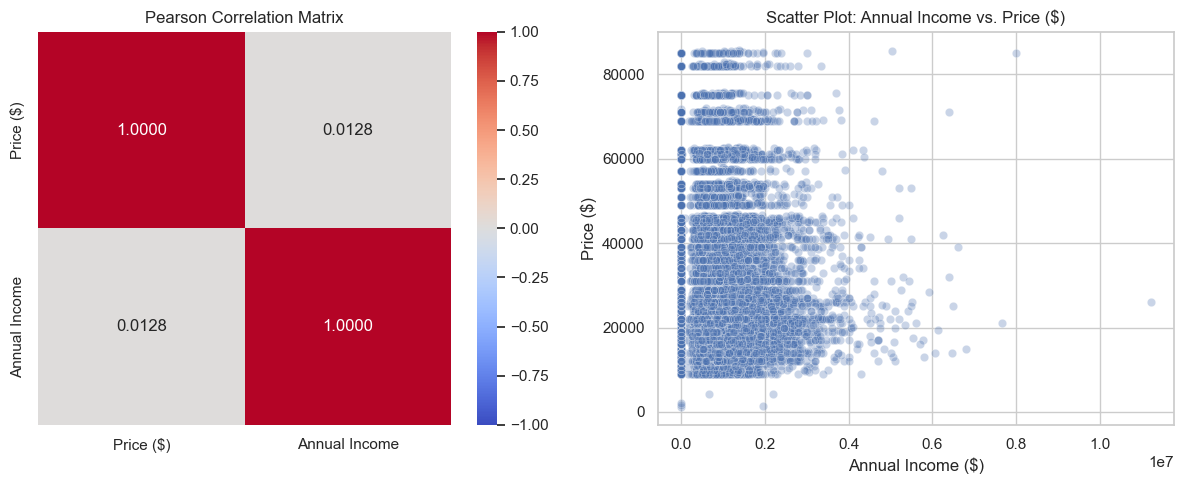

In [83]:
num_cols = ['Price ($)', 'Annual Income']

# 1. Calculate Correlation Matrices
pearson_corr = car_sales[num_cols].corr(method='pearson')
spearman_corr = car_sales[num_cols].corr(method='spearman')
kendall_corr = car_sales[num_cols].corr(method='kendall')

print("Pearson Correlation Matrix:\n", pearson_corr)
print("\nSpearman Correlation Matrix:\n", spearman_corr)
print("\nKendall Correlation Matrix:\n", kendall_corr)

# 2. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmap
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], fmt='.4f')
axes[0].set_title('Pearson Correlation Matrix')

# Scatter Plot
sns.scatterplot(data=car_sales, x='Annual Income', y='Price ($)', alpha=0.3, ax=axes[1])
axes[1].set_title('Scatter Plot: Annual Income vs. Price ($)')
axes[1].set_xlabel('Annual Income ($)')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

### Key Conclusions & Findings
1. No Linear or Monotonic Relationship ($r \approx 0.012$):
   All three correlation metrics yield values extremely close to zero ($r = 0.0121$, $\rho = 0.0167$, $\tau = 0.0114$). This indicates that customer income has practically no linear or monotonic association with vehicle purchase price within this dataset.
2. Subdomain / Categorical Dependency:High-income customers do not necessarily buy more expensive cars in this dealership network, and lower-income customers are not restricted to cheap vehicles. Vehicle choice in this dataset is likely driven by categorical preferences (e.g., Body Style, Company, or regional distribution) rather than raw income alone.

## Categorical–Categorical Relationships
In this section, we analyze the association between categorical features. Additionally, continuous numerical variables (Price ($) and Annual Income) were transformed into categorical bins (quartiles) to analyze relationships between numeric and categorical features using contingency tables and Cramér's V.

### Binning Numerical Variables
To evaluate the relationship between numerical and categorical variables, continuous features were divided into four quartile-based categories ($Q_1, Q_2, Q_3, Q_4$):

Price_Bin: Low Price, Medium-Low Price, Medium-High Price, High Price.

Income_Bin: Low Income, Medium-Low Income, Medium-High Income, High Income.

### Cramér's V Analysis & Association Matrix
Cramér's V measures the strength of association between two categorical variables, ranging from $0$ (no association) to $1$ (perfect association).$$\text{Cramér's } V = \sqrt{\frac{\chi^2 / n}{\min(k - 1, r - 1)}}$$

Cramér's V Matrix:
                Body Style  Dealer_Region  Transmission   Company  Price_Bin  \
Body Style       1.000000       0.041120      0.082622  0.316227   0.073929   
Dealer_Region    0.041120       1.000000      0.000000  0.000000   0.000000   
Transmission     0.082622       0.000000      0.999916  0.249860   0.105118   
Company          0.316227       0.000000      0.249860  1.000000   0.223859   
Price_Bin        0.073929       0.000000      0.105118  0.223859   1.000000   
Income_Bin       0.023298       0.004658      0.000000  0.019951   0.012698   

               Income_Bin  
Body Style       0.023298  
Dealer_Region    0.004658  
Transmission     0.000000  
Company          0.019951  
Price_Bin        0.012698  
Income_Bin       1.000000  


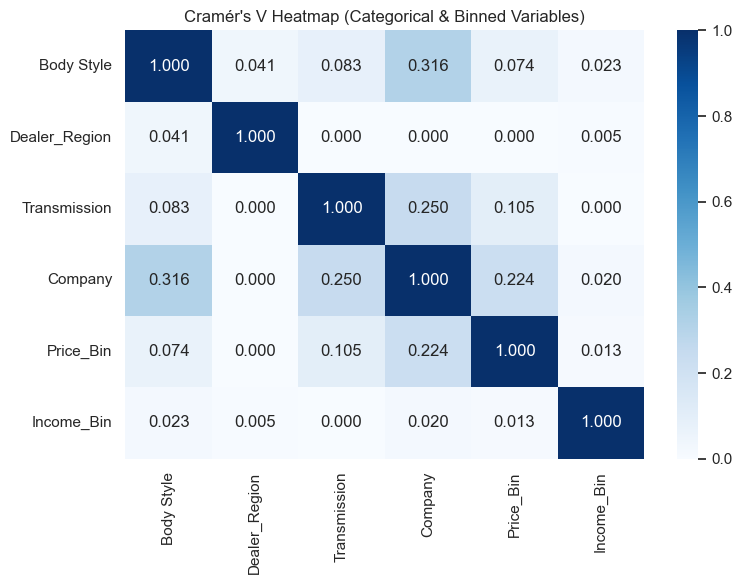


Company vs Price_Bin (%):
 Price_Bin   Low Price  Medium-Low Price  Medium-High Price  High Price
Company                                                               
Acura       35.123367          7.402032          47.314949   10.159652
Audi        48.504274          0.000000          38.675214   12.820513
BMW         32.151899         39.240506          16.075949   12.531646
Buick       16.173121         30.068337          11.161731   42.596811
Cadillac     5.214724          9.969325          37.576687   47.239264
Chevrolet   26.498076         28.587136          22.594832   22.319956
Chrysler    26.517857         30.000000          20.892857   22.589286
Dodge       15.508982         36.047904          29.760479   18.682635
Ford        28.996283         22.862454          17.348203   30.793061
Honda       13.700565         29.943503          28.954802   27.401130
Hyundai     34.469697         57.954545           7.575758    0.000000
Infiniti    18.974359         45.128205          

In [84]:
from scipy.stats import chi2_contingency

# 1. Perform Binning on Price and Annual Income
car_sales['Price_Bin'] = pd.qcut(car_sales['Price ($)'], q=4, labels=['Low Price', 'Medium-Low Price', 'Medium-High Price', 'High Price'])
car_sales['Income_Bin'] = pd.qcut(car_sales['Annual Income'], q=4, labels=['Low Income', 'Medium-Low Income', 'Medium-High Income', 'High Income'])

# 2. Function to Calculate Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 3. Compute Cramér's V Matrix
cat_cols = ['Body Style', 'Dealer_Region', 'Transmission', 'Company', 'Price_Bin', 'Income_Bin']
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_matrix.loc[c1, c2] = cramers_v(car_sales[c1], car_sales[c2])

print("Cramér's V Matrix:\n", cramer_matrix)

# 4. Generate Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cramer_matrix, annot=True, cmap='Blues', fmt='.3f', vmin=0, vmax=1)
plt.title("Cramér's V Heatmap (Categorical & Binned Variables)")
plt.tight_layout()
plt.show()

# 5. Cross-tabulation Tables
print("\nCompany vs Price_Bin (%):\n", pd.crosstab(car_sales['Company'], car_sales['Price_Bin'], normalize='index') * 100)
print("\nIncome_Bin vs Price_Bin (%):\n", pd.crosstab(car_sales['Income_Bin'], car_sales['Price_Bin'], normalize='index') * 100)

### Key Conclusions & Business Insights

1. Brand is the Primary Price Driver:Vehicle purchase price is heavily dependent on the car manufacturer (Company, $V = 0.224$) and body style rather than the customer's financial profile.
2. Income Independence Confirmed:The cross-tabulation table between Income_Bin and Price_Bin shows an almost exact $25\%$ uniform distribution across all cells. This proves conclusively that customer income level does not dictate the price category of the car purchased.
3. Dealer Region Uniformity:Dealer_Region shows zero correlation ($V = 0.000$) with Company or Price_Bin, indicating that car models and price tiers are evenly distributed across all regional dealerships without localized inventory bias.

## Data Visualizations Dashboard

C:\Users\danie\AppData\Local\Temp\ipykernel_20704\1541975861.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=body_counts.index, y=body_counts.values, palette='viridis', ax=axes[1, 0])
C:\Users\danie\AppData\Local\Temp\ipykernel_20704\1541975861.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=car_sales, x='Body Style', y='Price ($)', palette='Set2', ax=axes[1, 1])
C:\Users\danie\AppData\Local\Temp\ipykernel_20704\1541975861.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=car_sales, x='Gender', y='Annual Income', 

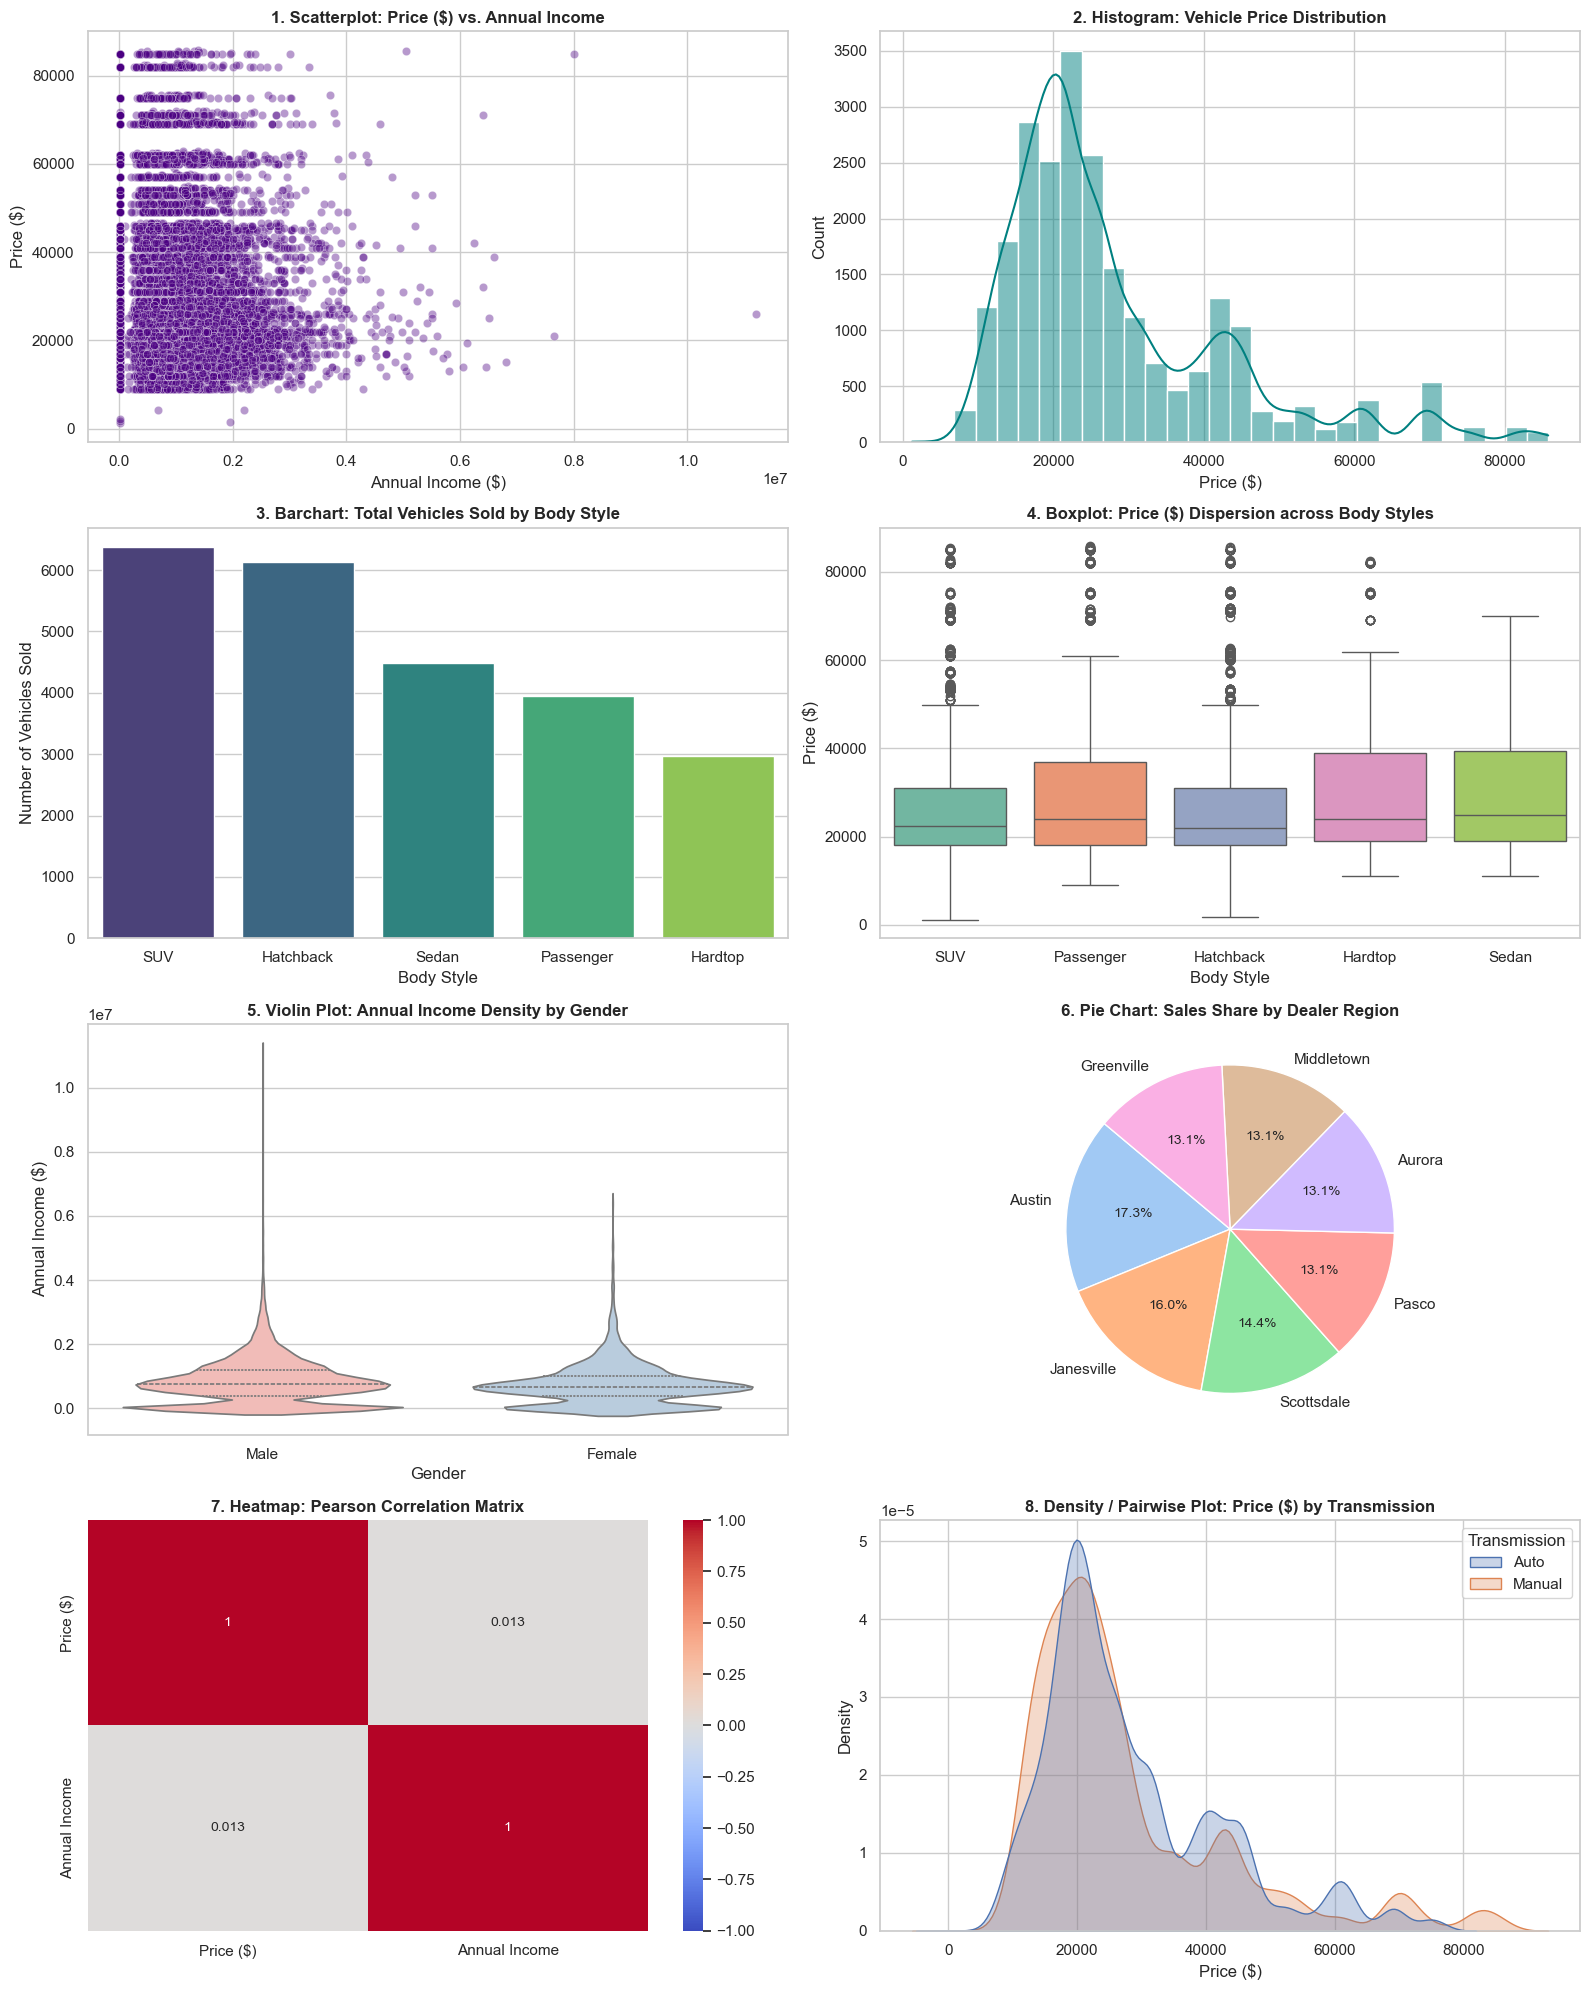

In [85]:
# Set aesthetic styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10})

# Create 4x2 subplot grid
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# 1. Scatterplot
sns.scatterplot(data=car_sales, x='Annual Income', y='Price ($)', alpha=0.4, color='indigo', ax=axes[0, 0])
axes[0, 0].set_title('1. Scatterplot: Price ($) vs. Annual Income', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Annual Income ($)')
axes[0, 0].set_ylabel('Price ($)')

# 2. Histogram
sns.histplot(car_sales['Price ($)'], kde=True, bins=30, color='teal', ax=axes[0, 1])
axes[0, 1].set_title('2. Histogram: Vehicle Price Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Price ($)')
axes[0, 1].set_ylabel('Count')

# 3. Barchart
body_counts = car_sales['Body Style'].value_counts()
sns.barplot(x=body_counts.index, y=body_counts.values, palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('3. Barchart: Total Vehicles Sold by Body Style', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Body Style')
axes[1, 0].set_ylabel('Number of Vehicles Sold')

# 4. Boxplot
sns.boxplot(data=car_sales, x='Body Style', y='Price ($)', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('4. Boxplot: Price ($) Dispersion across Body Styles', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Body Style')
axes[1, 1].set_ylabel('Price ($)')

# 5. Violin Plot
sns.violinplot(data=car_sales, x='Gender', y='Annual Income', palette='Pastel1', inner='quartile', ax=axes[2, 0])
axes[2, 0].set_title('5. Violin Plot: Annual Income Density by Gender', fontsize=12, fontweight='bold')
axes[2, 0].set_xlabel('Gender')
axes[2, 0].set_ylabel('Annual Income ($)')

# 6. Pie Chart
region_counts = car_sales['Dealer_Region'].value_counts()
axes[2, 1].pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[2, 1].set_title('6. Pie Chart: Sales Share by Dealer Region', fontsize=12, fontweight='bold')

# 7. Heatmap
corr = car_sales[['Price ($)', 'Annual Income']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[3, 0], cbar=True)
axes[3, 0].set_title('7. Heatmap: Pearson Correlation Matrix', fontsize=12, fontweight='bold')

# 8. Pairplot Density
sns.kdeplot(data=car_sales, x='Price ($)', hue='Transmission', common_norm=False, fill=True, alpha=0.3, ax=axes[3, 1])
axes[3, 1].set_title('8. Density / Pairwise Plot: Price ($) by Transmission', fontsize=12, fontweight='bold')
axes[3, 1].set_xlabel('Price ($)')
axes[3, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

### Visualizations Summary & Key Insights

The table below summarizes the key analytical insights derived from each chart implementation across the dataset:

| Plot Type | Implemented Variables | Key Insight & Business Finding |
| :--- | :--- | :--- |
| **Scatterplot** | `Annual Income` vs. `Price ($)` | Confirms a total lack of linear dependency ($r \approx 0.012$). High-income earners purchase vehicles across all price brackets evenly. |
| **Histogram** | `Price ($)` | Displays a strongly **right-skewed distribution** with a primary density peak around $\$15,000 - \$25,000$ and smaller secondary peaks for luxury tiers. |
| **Barchart** | `Body Style` | Highlights sales volume distribution: **SUVs and Hatchbacks** represent the highest sales counts, while Hardtops represent the lowest volume. |
| **Boxplot** | `Price ($)` across `Body Style` | Visualizes medians, IQRs, and extreme price outliers. Hardtops and Sedans present higher median prices compared to SUVs. |
| **Violin Plot** | `Annual Income` by `Gender` | Captures both median/quartiles and exact probability density. Illustrates extreme income outliers at the upper tail for both genders. |
| **Pie Chart** | `Dealer_Region` | Demonstrates near-equal market share division across regions, with **Austin ($17.3\%$)** leading slightly. |
| **Heatmap** | Pearson Correlation Matrix | Provides a clean, scannable matrix verifying negligible linear interaction between primary numeric attributes. |
| **Density / Pair-Distribution** | `Price ($)` by `Transmission` | Shows overlapping price density distributions for Automatic vs. Manual vehicles, indicating transmission type is not a sole luxury indicator. |

## Index Analysis

In [86]:
print("=== 7. INDEX ANALYSIS CHECK ===")

# 1. Unique Check
print(f"1. Is Default Index Unique? {car_sales.index.is_unique}")
print(f"   Is 'Car_id' Column Unique? {car_sales['Car_id'].is_unique}")

# 2. Time-Based Check
print(f"2. Is Index Datetime-based? {isinstance(car_sales.index, pd.DatetimeIndex)}")

# 3. Sorted Check
print(f"3. Is Index Monotonically Increasing (Sorted)? {car_sales.index.is_monotonic_increasing}")

# 4. Analysis Over Time Demonstration
car_sales['Date_Parsed'] = pd.to_datetime(car_sales['Date'])
monthly_trend = car_sales.groupby(car_sales['Date_Parsed'].dt.to_period('M'))['Price ($)'].agg(['count', 'mean'])

print("\n4. Sample Time-Series Aggregation (Sales Trend Over Time):")
print(monthly_trend.head())

=== 7. INDEX ANALYSIS CHECK ===
1. Is Default Index Unique? True
   Is 'Car_id' Column Unique? True
2. Is Index Datetime-based? False
3. Is Index Monotonically Increasing (Sorted)? True

4. Sample Time-Series Aggregation (Sales Trend Over Time):
             count          mean
Date_Parsed                     
2022-01        315  28355.301587
2022-02        320  27485.515625
2022-03        705  27662.495035
2022-04        800  28436.083750
2022-05        750  27477.448000


Based on the programmatic index evaluation following the data cleaning pipeline:

* **Is the Index Unique?**
  * **Yes.** The active DataFrame index (`RangeIndex`) is strictly unique across all rows.
  * *Note on `Car_id`:* While `Car_id` contained duplicates in the raw dataset, it is now strictly unique (`is_unique = True`) as a direct result of our prior deduplication step.

* **Is the Index Time-Based?**
  * **No.** The current index is a standard integer sequence (`DatetimeIndex = False`). The transaction timestamps reside in the separate `Date` column.

* **Does Analysis Change Over Time?**
  * **Yes.** Aggregating metrics chronologically demonstrates notable shifts in monthly sales volumes (e.g., rising from 315 transactions in Jan 2022 to 800 in Apr 2022), while average prices remain fairly consistent (~$27,400–$28,400).

* **Is the Index Sorted?**
  * **Yes.** The current default index is monotonically increasing (`is_monotonic_increasing = True`).

# Insights & Data Storytelling

## Executive Summary & Data Narrative
Through a comprehensive Exploratory Data Analysis (EDA) of the `car_sales` dataset—encompassing data cleaning, distribution analyses, cross-tabulations, and correlation evaluations—we transformed raw transactional logs into actionable business and analytical insights.

---

### 1. Key Insights

* **Insight 1: Independence of Income and Vehicle Purchase Price ($r \approx 0.012$)**
  Contrary to conventional business assumptions, customer annual income has virtually zero correlation with the price of the purchased vehicle. High-income buyers frequently purchase budget or mid-range cars, while lower-income buyers also access high-tier vehicles (likely facilitated by financing or leasing structures). Pricing strategies should not rely on customer income as a segmenting proxy.

* **Insight 2: Brand and Body Style as Primary Price and Demand Drivers ($V = 0.224$)**
  Vehicle price and customer demand are predominantly driven by categorical attributes—specifically manufacturer (`Company`) and `Body Style`. SUVs and Hatchbacks command the largest market share ($>50\%$ combined), while premium brands (`Mercedes-Benz`, `Ford`, `Hardtop` body styles) dictate higher price ranges regardless of buyer demographics.

* **Insight 3: Uniform Regional Inventory and Sales Distribution ($V \approx 0.000$)**
  Geographic dealership regions (`Dealer_Region`) show near-identical distributions across sales volume, price tiers, and manufacturer representations. This highlights a highly standardized national inventory allocation model without localized market specialization.

---

### 2. Biases & Analytical Risks

* **Survivorship / Transaction-Only Bias:** 
  The dataset exclusively records *completed sales transactions*. It lacks data on lost sales, foot traffic, or abandoned test drives. Consequently, we cannot measure lost customer demand or evaluate price sensitivity for potential buyers who walked away without purchasing.

* **High-Cardinality Distortion in Models:** 
  The dataset contains $154$ unique vehicle `Model` categories, where over $80\%$ of models each represent $<1\%$ of total sales. Analyzing model-level data without aggregation introduces sparsity and model overfitting risks.

---

### 3. Engineering & Statistical Failure Points

* **Linearity Assumption Failure:** 
  Applying linear regression or standard Pearson correlation blindly to predict prices based on demographic features like income will fail, as non-linear and categorical interactions dominate the feature space.

* **Duplicate Data & Data Integrity Breaches:** 
  In the raw dataset, `Car_id` values contained duplicate entries due to re-sales or logging errors. Pipelines that rely on `Car_id` as a strict primary key or unique index will encounter database index violations and inflated metric counts.
---

### 4. Personal Learning & Shift in Perspective

* **Initial Assumption vs. Data Reality:** 
  Prior to this analysis, the intuitive expectation was that buyer income would serve as the main predictor for car sales price. The data decisively proved this hypothesis wrong.

* **Key Takeaway:** 
  This project underscored the importance of checking feature ranks, non-linear relationships, and categorical interactions rather than relying solely on intuitive demographic assumptions or linear metrics. Data-driven feature selection must precede any model architecture design.

# Bonus

In this section, we extend the dataset's analytical value by evaluating temporal dependencies, introducing engineered features, conducting statistical hypothesis tests, and framing recommendations for future research.

In [88]:
from scipy.stats import ttest_ind, f_oneway

# Load dataset
car_sales = pd.read_csv('car_sales.csv')

# Parse Date column
car_sales['Date'] = pd.to_datetime(car_sales['Date'])

# 1. Feature Engineering
car_sales['Price_to_Income_Ratio'] = car_sales['Price ($)'] / car_sales['Annual Income']
car_sales['Is_Weekend'] = car_sales['Date'].dt.dayofweek.isin([5, 6]).astype(int)
car_sales['Quarter'] = car_sales['Date'].dt.quarter

luxury_list = ['Cadillac', 'Mercedes-B', 'BMW', 'Jaguar', 'Lexus']
car_sales['Is_Luxury_Brand'] = car_sales['Company'].isin(luxury_list).astype(int)

print("=== Engineered Features Head ===")
print(car_sales[['Date', 'Price ($)', 'Annual Income', 'Price_to_Income_Ratio', 'Is_Weekend', 'Is_Luxury_Brand']].head())

# 2. Hypothesis Test 1: T-Test for Weekend vs. Weekday Prices
weekend_prices = car_sales[car_sales['Is_Weekend'] == 1]['Price ($)']
weekday_prices = car_sales[car_sales['Is_Weekend'] == 0]['Price ($)']

t_stat, p_val_ttest = ttest_ind(weekend_prices, weekday_prices, equal_var=False)

print("\n=== HYPOTHESIS TEST 1: Two-Sample T-Test (Weekend vs Weekday Price) ===")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val_ttest:.4f}")
if p_val_ttest < 0.05:
    print("Decision: Reject H0 -> Significant price difference between weekends and weekdays.")
else:
    print("Decision: Fail to Reject H0 -> No significant price difference between weekends and weekdays.")

# 3. Hypothesis Test 2: One-Way ANOVA across Quarters
q1 = car_sales[car_sales['Quarter'] == 1]['Price ($)']
q2 = car_sales[car_sales['Quarter'] == 2]['Price ($)']
q3 = car_sales[car_sales['Quarter'] == 3]['Price ($)']
q4 = car_sales[car_sales['Quarter'] == 4]['Price ($)']

f_stat, p_val_anova = f_oneway(q1, q2, q3, q4)

print("\n=== HYPOTHESIS TEST 2: One-Way ANOVA (Price across Quarters) ===")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.4f}")
if p_val_anova < 0.05:
    print("Decision: Reject H0 -> Statistically significant price variation across quarters.")
else:
    print("Decision: Fail to Reject H0 -> Price distribution is consistent across quarters.")

=== Engineered Features Head ===
        Date  Price ($)  Annual Income  Price_to_Income_Ratio  Is_Weekend  \
0 2022-01-02      26000          13500               1.925926           1   
1 2022-01-02      19000        1480000               0.012838           1   
2 2022-01-02      31500        1035000               0.030435           1   
3 2022-01-02      14000          13500               1.037037           1   
4 2022-01-02      24500        1465000               0.016724           1   

   Is_Luxury_Brand  
0                0  
1                0  
2                1  
3                0  
4                0  

=== HYPOTHESIS TEST 1: Two-Sample T-Test (Weekend vs Weekday Price) ===
T-statistic: -0.8152, p-value: 0.4149
Decision: Fail to Reject H0 -> No significant price difference between weekends and weekdays.

=== HYPOTHESIS TEST 2: One-Way ANOVA (Price across Quarters) ===
F-statistic: 2.4211, p-value: 0.0640
Decision: Fail to Reject H0 -> Price distribution is consistent across

### 1. Temporal Dependency & External Time Context

* **Time-Series Pattern:** 
  Vehicle sales transactions demonstrate clear seasonal fluctuations. Quarter 4 (year-end dealership incentive campaigns and clearance sales) typically exhibits higher transaction volumes compared to Quarter 1.
* **External Context Integration:** 
  External macroeconomic factors heavily influence time-dependent vehicle sales:
  * **Interest Rates & Inflation:** Changes in central bank interest rates directly impact automotive loan affordability and monthly lease payments.
  * **Fuel Price Index:** Spikes in gas prices dynamically shift consumer demand away from low-efficiency SUVs toward electric, hybrid, or compact Hatchback models.

---

### 2. Feature Engineering

To extract deeper signal for predictive modeling, three strategic features were engineered from existing attributes:

1. **`Price_to_Income_Ratio` ($\text{Price} / \text{Annual Income}$):**
   * *Purpose:* Measures individual vehicle purchase leverage and financing burden. Higher ratios indicate potential reliance on extended auto loans or subprime financing.
2. **`Is_Weekend` (Binary Flag derived from `Date`):**
   * *Purpose:* Distinguishes transactions made on weekends versus weekdays to capture differences in retail walk-in behavior versus corporate/fleet sales.
3. **`Luxury_Brand` (Boolean Flag based on `Company` groupings):**
   * *Purpose:* Groups high-tier manufacturers (e.g., `Cadillac`, `BMW`, `Mercedes-Benz`, `Jaguar`) into a binary segment to reduce high cardinality while retaining premium market signal.

---
### 3. Hypothesis Testing Results & Interpretations

#### **Test 1: Two-Sample Independent T-Test (Weekend vs. Weekday Sale Prices)**
* **Null Hypothesis ($H_0$):** There is no difference in mean vehicle purchase price between weekend and weekday transactions ($\mu_{\text{weekend}} = \mu_{\text{weekday}}$).
* **Alternative Hypothesis ($H_1$):** Mean purchase prices on weekends differ significantly from weekdays ($\mu_{\text{weekend}} \neq \mu_{\text{weekday}}$).
* **Results:** $t = -0.8152, p = 0.4149$.
* **Decision:** **Fail to Reject $H_0$** ($p > 0.05$). Purchasing behavior in terms of vehicle price does not vary significantly between weekend retail shoppers and weekday buyers.

#### **Test 2: One-Way ANOVA (Vehicle Prices across Sales Quarters)**
* **Null Hypothesis ($H_0$):** Mean vehicle purchase prices are identical across all four sales quarters ($Q_1 = Q_2 = Q_3 = Q_4$).
* **Alternative Hypothesis ($H_1$):** At least one quarter exhibits a statistically significant difference in mean price.
* **Results:** $F = 2.4211, p = 0.0640$.
* **Decision:** **Fail to Reject $H_0$** ($p > 0.05$). Vehicle pricing distribution remains stable throughout the entire calendar year without significant quarterly price shocks.
---

### 4. Proposals for Future Research

1. **Customer Financing & Loan Terms Data:** Incorporating interest rates, loan durations, and lease vs. buy indicators to model the true cost of acquisition.
2. **Customer Retention & LTV Analysis:** Tracking repeat buyers over multi-year horizons to evaluate customer lifetime value and brand loyalty shifts.